<a href="https://colab.research.google.com/github/Sangeetha231005/MLops-training/blob/main/Logistic_Regression_Flood_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Logistic Regression - Flood Detection**

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Flood_detection/flood.csv")

In [ ]:
df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [ ]:
df.shape

(50000, 21)

In [ ]:
df['Flood'] = (df['FloodProbability'] > 0.5).astype(int)

In [ ]:
df[['FloodProbability', 'Flood']].head(20)

,FloodProbability,Flood
0,0.450,0
1,0.475,0
2,0.515,1
3,0.520,1
4,0.475,0
5,0.470,0
6,0.570,1
7,0.585,1
8,0.580,1
9,0.555,1


In [ ]:
df.shape

(50000, 22)

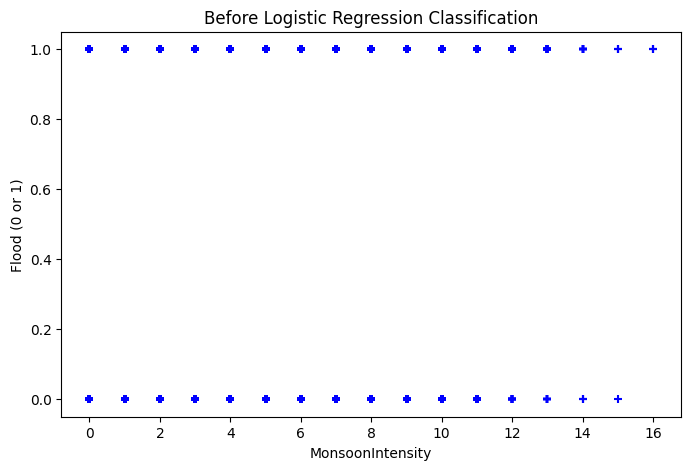

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['MonsoonIntensity'],
    df['Flood'],
    color='blue',
    marker='+'
)
plt.xlabel("MonsoonIntensity")
plt.ylabel("Flood (0 or 1)")
plt.title("Before Logistic Regression Classification")
plt.show()

In [ ]:
X = df.drop(['FloodProbability', 'Flood'], axis=1)

In [ ]:
y = df['Flood']

In [ ]:
X.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
0,3,8,6,6,4,4,6,2,3,2,5,10,7,4,2,3,4,3,2,6
1,8,4,5,7,7,9,1,5,5,4,6,9,2,6,2,1,1,9,1,3
2,3,10,4,1,7,5,4,7,4,9,2,7,4,4,8,6,1,8,3,6
3,4,4,2,7,3,4,1,4,6,4,9,4,2,6,6,8,8,6,6,10
4,3,7,5,2,5,8,5,2,7,5,7,7,6,5,3,3,4,4,3,4


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=10
)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_predicted = model.predict(X_test)

In [ ]:
y_predicted

array([1, 0, 1, ..., 1, 1, 0])

In [ ]:
model.predict_proba(X_test)

array([[6.36200411e-02, 9.36379959e-01],
       [1.00000000e+00, 4.67097900e-18],
       [0.00000000e+00, 1.00000000e+00],
       ...,
       [0.00000000e+00, 1.00000000e+00],
       [4.23161506e-11, 1.00000000e+00],
       [1.00000000e+00, 1.34229229e-22]])

In [ ]:
model.score(X_test, y_test)

1.0

In [ ]:
model.coef_

array([[5.30795746, 5.2977545 , 5.28676749, 5.29663067, 5.29760263,
        5.30152933, 5.31023943, 5.2994802 , 5.30114028, 5.3137901 ,
        5.2950101 , 5.30275874, 5.32607255, 5.31091679, 5.30732351,
        5.30642435, 5.31146277, 5.29703918, 5.29480391, 5.30222525]])

In [ ]:
model.intercept_

array([-533.01363912])

In [ ]:
import math
def sigmoid(x):
    return 1 / (1 + math.exp(-x))

In [ ]:
def flood_prediction(features):
    z = np.dot(model.coef_[0], features) + model.intercept_[0]
    y = sigmoid(z)
    return y

In [ ]:
sample = [7,8,6,5,7,9,4,8,6,5,7,8,6,5,7,6,8,5,4,6]

In [ ]:
result = flood_prediction(sample)
print(result)

1.0
